<a href="https://colab.research.google.com/github/nilum2002/Fine-Tune-LLMs-/blob/Main/FineTuneLlama2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
!pip install -U \
    accelerate==1.6.0 \
    peft==0.15.2 \
    bitsandbytes==0.45.5 \
    transformers==4.52.4 \
    trl==0.9.6 \
    datasets==3.2.0



In [22]:
# # for CUDA out of memory
# import os
# os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"


In [17]:
import os
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig,
    HfArgumentParser,
    TrainingArguments,
    pipeline,
    logging
)
from trl import SFTTrainer
from peft import LoraConfig, PeftModel
from datasets import load_dataset
import torch


In Case of Llama 2, the following prompt template is used for the chat models

1. The System Prompt(Optional) - To guid the model
2. The User Prompt(required) -  To give the instructions
3. Model Answer(required)

    



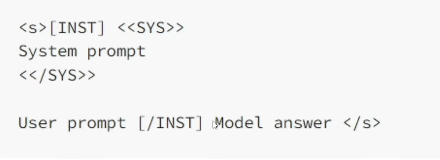

We will reformat our instruction dataset to follow Llama 2 template

The Original dataset : https://huggingface.co/datasets/timdettmers/openassistant-guanaco/viewer?views%5B%5D=train

We convert this to lamma2 format(converted Dataset) : https://huggingface.co/datasets/gpjt/openassistant-guanaco-llama2-format



1. Load a llama-2-7b-chat-hf model (chat model)
2. Train it on the mlabonne/guanaco-llama2-1k (1000 samples) which will produce our finetuned model Llama-2-7b-chat-finetune

QLORA will use a rank of 64 with a scaling parameter of 16. We will load the Llama2 model directly in 4-bit precision using the NF4 type and train it for one epoch.


In [25]:
# model want to train
model_name = "NousResearch/Llama-2-7b-chat-hf"

# the instruction dataset
dataset_name = "mlabonne/guanaco-llama2-1k"

# fine tuned model
new_model = "Llama-2-7b-chat-finetune"

##########################################################################
# QLoRA parameters
##########################################################################

# LoRA attention dimension
lora_r = 64

# Alpha parameter for LoRA scaling
lora_alpha = 16

# Droupout proberbility
lora_dropout = 0.1

##########################################################################
# BitsAndBytes Parameters
##########################################################################

# Active 4 bit precision base model loading
use_4bit = True

# Compute the dtype for 4-bit base models
bnb_4bit_compute_dtype = torch.float16

# Quntization type (fp4 or nf4)
bnb_4bit_quant_type = "nf4"

# active nested quamtization for 4 bit base models (double qi=untization)
use_nested_quant = True

##########################################################################
# TrainingArgumentParameters
##########################################################################

# output directory where the model predictions and checkpoints will be stored
output_dir = "./results"

# number of training epochs
num_train_epochs  = 1

# enable fp16/bf16 training (set bf16 to true with an A100)
fp16 = False
bf16 = False

# batch size per GPU for Training
per_device_train_batch_size = 1

# batch size per GPU for eveluvation
per_device_eval_batch_size = 4

# number of update steps to accumulate the gradients for
gradient_accumulation_steps = 16

# enable gradient checkpoints
gradient_checkpointing = True

# Maximum gradinet normal (gradient clipping)
max_grad_norm = 0.3

# initial learing rate(AsamW optimizer)
learning_rate = 2e-4

# weight decay to apply to all layers expect bias/layerNorm weights
weight_decay = 0.001

# optimizer to use
optim = "paged_adamw_32bit"

# learning rate schedule
lr_scheduler_type = "cosine"

# number of training steps (override num_train_epochs)
max_steps = -1

# Ratio of steps for a linear warmup (from 0 to learing rate)
warmup_ratio = 0.03

# group sequnces into batches with same length
# saves memory and speeds up training considerably
group_by_length = True

# Save checkpoint evey x update steps
save_step = 0

# log every X updates steps
logging_steps = 25

##########################################################################
# SFT parameters
##########################################################################

# Maximum sequnce length to use
max_seq_length = 1024

# pack multiple short examples in the same input sequnce to increase efficiency
packing = False

# Load the entire model on the GPU 0
device_map = {"":0}

1. Load the dataset we defined. Here Our Dataset is already preprocessed but usually, this is where you would reformat the prompt, filter out bad text, combine multiple datasets etc.

2. Then We are configuring bitsandbytes for 4-bit quntization

3. Next, we are loading the Llama 2 model ub 4-bit precision on a GPU with the corresponding  tokenizer

4. Finally, we are loading configurations for QLoRA, regular training parameters and passing everything to the SFTTrainer.

Note:
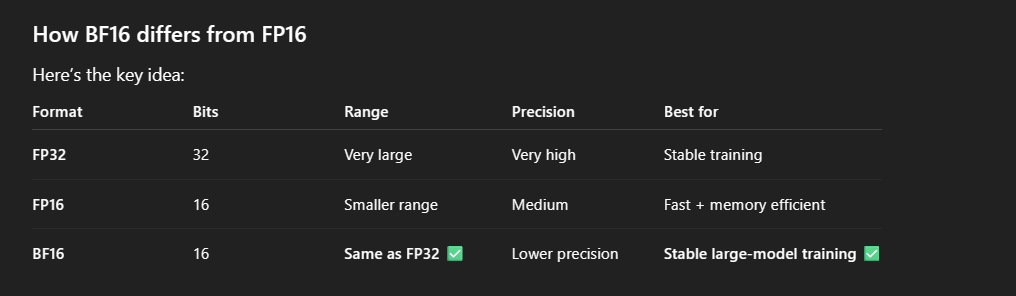
The Train can finally start ... !

In [27]:
from transformers.utils import quantization_config
# load the dataset
dataset = load_dataset(dataset_name, split = "train")

# load tokenizer and model with QLoRA configuration
# compute_dtype = getattr(torch, bnb_4bit_compute_dtype)
compute_dtype = bnb_4bit_compute_dtype

bnb_config = BitsAndBytesConfig(
    load_in_4bits = use_4bit,
    bnb_4bit_quant_type=bnb_4bit_quant_type,
    bnb_4bit_compute_dtype=bnb_4bit_compute_dtype,
    bnb_4bit_use_double_quant=use_nested_quant,
)

# check the GPU compatibility with bfloat16
if compute_dtype == torch.float16 and use_4bit:
  major,_ = torch.cuda.get_device_capability()
  if major >= 8 :
    print("="*80)
    print("Your GPU supports bfloat16: Accelarate training with bf16=True")
    print("="*80)

# load base model
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map=device_map,
)

model.config.use_cache = False
model.config.pretraining_tp = 1

# Load LLaM tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code = True)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right" # fix weird overflow issue with fo16 training

# Load Lora Configurations
peft_config = LoraConfig(
    lora_alpha = lora_alpha,
    lora_dropout = lora_dropout,
    r = lora_r,
    bias = "none",
    task_type = "CAUSAL_LM"
)

# set training parameters
# training_arguments = TrainingArguments(
#     output_dir = output_dir,
#     num_train_epochs = num_train_epochs,
#     per_device_train_batch_size = per_device_train_batch_size,
#     gradient_accumulation_steps = gradient_accumulation_steps,
#     optim = optim,
#     save_steps = save_step,
#     logging_steps = logging_steps,
#     learning_rate = learning_rate,
#     weight_decay = weight_decay,
#     fp16 = fp16,
#     bf16=bf16,
#     max_grad_norm = max_grad_norm,
#     max_steps=max_steps,
#     warmup_ratio = warmup_ratio,
#     group_by_length = group_by_length,
#     lr_scheduler_type = lr_scheduler_type,
#     report_to = "tensorboard"
# )
training_arguments = TrainingArguments(
    output_dir=output_dir,
    num_train_epochs=3,
    per_device_train_batch_size=1,
    gradient_accumulation_steps=16,
    optim="paged_adamw_32bit",
    save_steps=1000,
    logging_steps=50,
    learning_rate=2e-4,
    fp16=True,
    bf16=False,
    max_grad_norm=0.3,
    warmup_ratio=0.03,
    group_by_length=True,
    report_to="tensorboard",
)


# set supervised fine tuning parameters
trainer = SFTTrainer(
    model = model,
    train_dataset=dataset,
    peft_config=peft_config,
    dataset_text_field = "text",
    max_seq_length = max_seq_length,
    tokenizer = tokenizer,
    args = training_arguments,
    packing=packing,
)

# train model
trainer.train()


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

'(ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: c2b359f3-e4f6-461e-8239-164d286bb946)')' thrown while requesting HEAD https://huggingface.co/NousResearch/Llama-2-7b-chat-hf/resolve/main/custom_generate/generate.py
Retrying in 1s [Retry 1/5].
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_deprecation.py:100: FutureWarning: Deprecated argument(s) used in '__init__': dataset_text_field, max_seq_length. Will not be supported from version '1.0.0'.

Deprecated positional argument(s) used in SFTTrainer, please use the SFTConfig to set these arguments instead.
  warnings.warn(message, FutureWarning)
/usr/local/lib/python3.12/dist-packages/trl/trainer/sft_trainer.py:280: UserWarning: You passed a `max_seq_length` argument to the SFTTrainer, the value you passed will override the one in the `SFTConfig`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/trl/trainer/sft_trainer.py:318: UserWarning: 

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/trl/trainer/sft_trainer.py:413: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `SFTTrainer.__init__`. Use `processing_class` instead.
  super().__init__(
No label_names provided for model class `PeftModelForCausalLM`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


Step,Training Loss
50,1.547300
100,1.316200
150,1.279200


'(ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: 137263bf-db5b-47dd-9cf4-4b5466b3c80e)')' thrown while requesting HEAD https://huggingface.co/NousResearch/Llama-2-7b-chat-hf/resolve/main/config.json
Retrying in 1s [Retry 1/5].
'(ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: 1ea2c0ee-c6e0-40be-890b-fc844fa2afed)')' thrown while requesting HEAD https://huggingface.co/NousResearch/Llama-2-7b-chat-hf/resolve/main/config.json
Retrying in 2s [Retry 2/5].
'(ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: dc263618-2e09-450b-a7d5-54c1ca7f76bd)')' thrown while requesting HEAD https://huggingface.co/NousResearch/Llama-2-7b-chat-hf/resolve/main/config.json
Retrying in 4s [Retry 3/5].


TrainOutput(global_step=189, training_loss=1.3622034466455852, metrics={'train_runtime': 4664.992, 'train_samples_per_second': 0.643, 'train_steps_per_second': 0.041, 'total_flos': 5.038628653264896e+16, 'train_loss': 1.3622034466455852, 'epoch': 3.0})